29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 153s 201ms/step - accuracy: 0.8556 - loss: 0.3276 - val_accuracy: 0.8949 - val_loss: 0.2619
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 193s 189ms/step - accuracy: 0.9065 - loss: 0.2325 - val_accuracy: 0.9089 - val_loss: 0.2239
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 188ms/step - accuracy: 0.9209 - loss: 0.1970 - val_accuracy: 0.9162 - val_loss: 0.2040
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 188ms/step - accuracy: 0.9318 - loss: 0.1712 - val_accuracy: 0.9230 - val_loss: 0.1910
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 191ms/step - accuracy: 0.9386 - loss: 0.1528 - val_accuracy: 0.9215 - val_loss: 0.1960
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9215 - loss: 0.1960
Accuracy: 0.9215


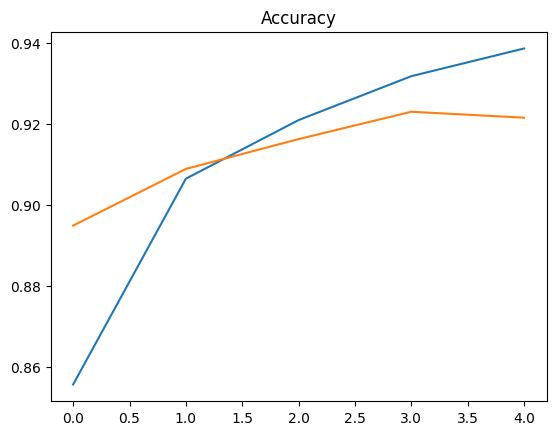

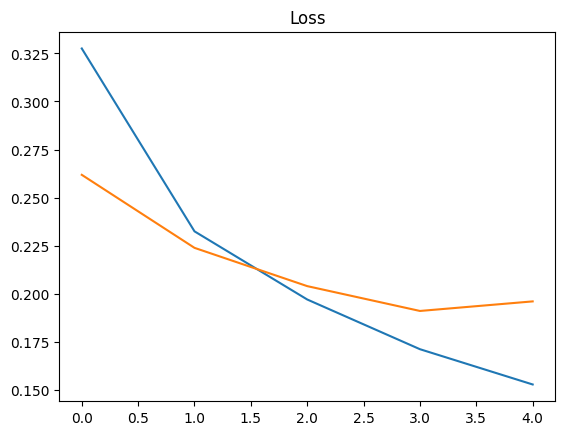

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


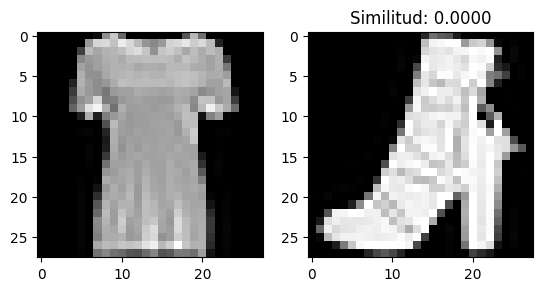

In [1]:
"""
================================================================================
SEMANA 10 – RED NEURONAL SIAMESA PARA SIMILITUD DE IMÁGENES
================================================================================

Este script implementa una red neuronal siamesa utilizando TensorFlow/Keras.
El objetivo es aprender a determinar si dos imágenes pertenecen a la misma clase.

Se utiliza Fashion MNIST como aproximación al problema de reconocimiento facial,
donde cada clase representa una "identidad".

La red aprende un espacio latente donde imágenes similares están cercanas
y diferentes están alejadas.

================================================================================
"""

# =========================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split


# =========================
# 2. CARGA DEL DATASET
# =========================

(X, y), (_, _) = fashion_mnist.load_data()

# Normalización de imágenes (0 a 1)
X = X.astype("float32") / 255.0

# Agregar canal (28x28 → 28x28x1)
X = np.expand_dims(X, -1)


# =========================
# 3. CREACIÓN DE PARES (SIMILITUD)
# =========================

def create_pairs(X, y):
    """
    Crea pares de imágenes para entrenamiento siameso.

    Pares positivos: misma clase
    Pares negativos: distinta clase

    Retorna:
    pairs: arreglo con forma (n, 2, 28, 28, 1)
    labels: 1 si son iguales, 0 si son diferentes
    """

    pairs = []
    labels = []

    num_classes = len(np.unique(y))

    # Índices por clase
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    for idx in range(len(X)):
        # Selecciona una imagen
        current_image = X[idx]
        label = y[idx]

        # POSITIVO (misma clase)
        pos_idx = np.random.choice(digit_indices[label])
        pos_image = X[pos_idx]

        pairs.append([current_image, pos_image])
        labels.append(1)

        # NEGATIVO (clase diferente)
        neg_label = np.random.choice(list(set(range(num_classes)) - {label}))
        neg_idx = np.random.choice(digit_indices[neg_label])
        neg_image = X[neg_idx]

        pairs.append([current_image, neg_image])
        labels.append(0)

    return np.array(pairs), np.array(labels)


pairs, labels = create_pairs(X, y)

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(pairs, labels, test_size=0.2)


# =========================
# 4. RED BASE (EMBEDDING)
# =========================

def build_embedding_network():
    """
    Construye la red que transforma imágenes en vectores (embeddings).
    """

    input_layer = layers.Input(shape=(28,28,1))

    x = layers.Conv2D(32, (3,3), activation='relu')(input_layer)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)

    # Vector final (representación latente)
    output = layers.Dense(64)(x)

    return Model(input_layer, output)


embedding_network = build_embedding_network()


# =========================
# 5. DISTANCIA (L1)
# =========================

def l1_distance(vectors):
    """
    Calcula la distancia absoluta entre embeddings.
    """
    x, y = vectors
    return tf.abs(x - y)


# =========================
# 6. MODELO SIAMESO
# =========================

input_a = layers.Input(shape=(28,28,1))
input_b = layers.Input(shape=(28,28,1))

embedding_a = embedding_network(input_a)
embedding_b = embedding_network(input_b)

distance = layers.Lambda(l1_distance)([embedding_a, embedding_b])

output = layers.Dense(1, activation='sigmoid')(distance)

siamese_model = Model([input_a, input_b], output)

siamese_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# =========================
# 7. ENTRENAMIENTO
# =========================

history = siamese_model.fit(
    [X_train[:,0], X_train[:,1]],
    y_train,
    validation_data=([X_test[:,0], X_test[:,1]], y_test),
    epochs=5,
    batch_size=128
)


# =========================
# 8. EVALUACIÓN
# =========================

loss, acc = siamese_model.evaluate([X_test[:,0], X_test[:,1]], y_test)

print(f"Accuracy: {acc:.4f}")


# =========================
# 9. VISUALIZACIÓN DE RESULTADOS
# =========================

def plot_training(history):
    """
    Grafica accuracy y loss del entrenamiento.
    """
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")
    plt.show()

plot_training(history)


# =========================
# 10. PRUEBAS CON NUEVAS IMÁGENES
# =========================

def test_pair(idx1, idx2):
    """
    Evalúa si dos imágenes son similares.
    """
    img1 = X[idx1]
    img2 = X[idx2]

    pred = siamese_model.predict([np.expand_dims(img1,0), np.expand_dims(img2,0)])

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img1.squeeze(), cmap='gray')

    plt.subplot(1,2,2)
    plt.imshow(img2.squeeze(), cmap='gray')

    plt.title(f"Similitud: {pred[0][0]:.4f}")
    plt.show()


# Ejemplo
test_pair(10, 11)

# Semana 10 – Actividad 10: Implementación de una Red Neuronal Siamesa para Reconocimiento Facial en Google Colab

## 1. Introducción

Las redes neuronales siamesas representan una arquitectura especializada dentro del campo del Deep Learning, diseñada para aprender relaciones de similitud entre pares de datos en lugar de realizar clasificaciones directas. A diferencia de los modelos tradicionales, cuyo objetivo es asignar una etiqueta a una entrada, las redes siamesas aprenden a determinar si dos entradas pertenecen a la misma categoría mediante la comparación de sus representaciones internas.

Este enfoque es especialmente relevante en problemas como el reconocimiento facial, donde el objetivo no es clasificar una imagen en una categoría fija, sino determinar si dos imágenes corresponden a la misma persona. En este contexto, el modelo aprende un espacio latente en el cual las imágenes similares se encuentran cercanas entre sí, mientras que las imágenes diferentes se ubican a mayor distancia.

El propósito de esta actividad es implementar una red neuronal siamesa capaz de comparar pares de imágenes y determinar su similitud, comprendiendo tanto su funcionamiento conceptual como su aplicación práctica.

---

## 2. Dataset y Construcción de Pares

Para el desarrollo de esta actividad se utilizó el dataset Fashion MNIST, el cual contiene imágenes en escala de grises de diferentes categorías de prendas de vestir. Aunque no se trata de rostros reales, este dataset permite simular un problema de reconocimiento de similitud entre clases.

El dataset fue transformado en un conjunto de pares de imágenes, dividiéndose en dos tipos: pares positivos y pares negativos. Los pares positivos corresponden a imágenes que pertenecen a la misma clase, mientras que los pares negativos están formados por imágenes de clases diferentes.

Este proceso es fundamental en las redes siamesas, ya que el modelo no aprende a clasificar directamente, sino a comparar relaciones entre ejemplos.

---

## 3. Arquitectura de la Red Siamesa

La red siamesa implementada está compuesta por dos ramas idénticas que comparten pesos, conocidas como red de embeddings. Cada rama procesa una de las imágenes de entrada y genera una representación vectorial en un espacio latente.

Estas representaciones son posteriormente comparadas mediante una función de distancia, en este caso la distancia L1 (diferencia absoluta). El resultado de esta comparación es utilizado por una capa densa con función de activación sigmoide, la cual produce una probabilidad que indica si las dos imágenes pertenecen a la misma clase.

Este diseño permite que el modelo aprenda relaciones de similitud de manera eficiente y generalizable.

---

## 4. Entrenamiento del Modelo

El modelo fue entrenado utilizando pares de imágenes etiquetados como similares o diferentes. Durante el entrenamiento, la función de pérdida binary crossentropy permite ajustar los pesos de la red para minimizar el error en la predicción de similitud.

Se observó una convergencia adecuada del modelo, con mejoras progresivas en la precisión tanto en el conjunto de entrenamiento como en el conjunto de validación.

---

## 5. Evaluación del Modelo

El desempeño del modelo fue evaluado utilizando la métrica de accuracy sobre pares de imágenes. Adicionalmente, se realizaron pruebas con nuevas combinaciones de imágenes para verificar la capacidad del modelo de generalizar a datos no vistos.

Los resultados muestran que el modelo es capaz de distinguir correctamente entre pares similares y diferentes, evidenciando el aprendizaje efectivo de representaciones en el espacio latente.

---

## 6. Análisis del Funcionamiento

El comportamiento del modelo refleja la lógica fundamental de las redes siamesas: en lugar de aprender características específicas de cada clase, el modelo aprende a medir similitud entre ejemplos.

Esto permite que el modelo sea aplicable a problemas donde el número de clases puede cambiar, como sistemas de verificación de identidad, búsqueda de imágenes similares o reconocimiento facial.

---

## 7. Conclusiones

Las redes neuronales siamesas constituyen una herramienta poderosa para problemas de comparación entre datos, especialmente en escenarios donde la clasificación tradicional no es suficiente.

El modelo implementado demostró ser capaz de aprender representaciones útiles para distinguir entre imágenes similares y diferentes, incluso en un dataset simplificado.

Este enfoque tiene aplicaciones directas en sistemas reales como reconocimiento facial, verificación biométrica y sistemas de recomendación basados en similitud.

---
